In [1]:
import copy
import sys
import warnings
warnings.filterwarnings('ignore')

from arch import arch_model
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit

from statsforecast.arima import arima_string
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.multitest import multipletests

from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse


sys.path.append("/Users/nikolaj/Desktop/Education/DataScience/Operations Research/repo/")


from src.preprocessing import preporocess, take_n
from src.cross_validation import mae_crossval

In [2]:
df = pd.read_csv("../data/kz.csv")
df = preporocess(df)

## Take n best sold

In [3]:
prod_idx, prod_list, nr_orders_week  = take_n(df, 100)

In [4]:
prod_list[prod_idx[0]].head()

date
2020-01-12      9
2020-01-19    150
2020-01-26    322
2020-02-02    177
2020-02-09    143
Name: order_nr, dtype: int64

## Auto ARIMA

In [9]:
# structure df in to a format required for the statsforecast
df_for_fit = pd.DataFrame({
    "unique_id": nr_orders_week.index.get_level_values(0),
    "ds": nr_orders_week.index.get_level_values(1),
    "y": nr_orders_week.values
})
print(df_for_fit.head())

             unique_id          ds    y
0  1515966223509088521  2020-01-12    9
1  1515966223509088521  2020-01-19  150
2  1515966223509088521  2020-01-26  322
3  1515966223509088521  2020-02-02  177
4  1515966223509088521  2020-02-09  143


In [113]:
# fit ARIMA for every series with AutoARIMA 
sf = StatsForecast(
    models=[
        AutoARIMA(
            # season_length=13,
            start_p=0,
            start_q=0,
            max_d=2
        )
    ],
    freq="W",
    n_jobs=-1
)

sf.fit(df_for_fit[df_for_fit["unique_id"] == prod_idx[69]]);

In [114]:
cv = sf.cross_validation(
    df=df_for_fit[df_for_fit["unique_id"] == prod_idx[69]],
    h=8,
    n_windows=3
)

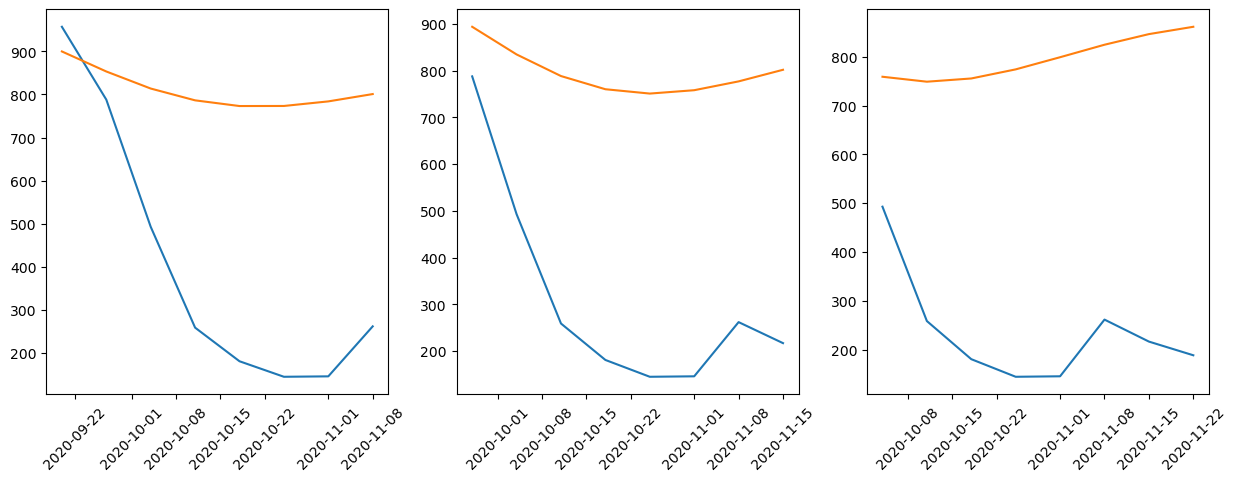

In [115]:
h = 8
n_windows = 3
lst = [cv[cv["unique_id"] == prod_idx[69]][i:i+h] for i in range(0, h * n_windows - 1, h)]

fig, axs = plt.subplots(1, n_windows, figsize=(15, 5))

for i, d in enumerate(lst):
    axs[i].plot(d.ds, d.y)
    axs[i].plot(d.ds, d.AutoARIMA)
    axs[i].tick_params("x", labelrotation=45)


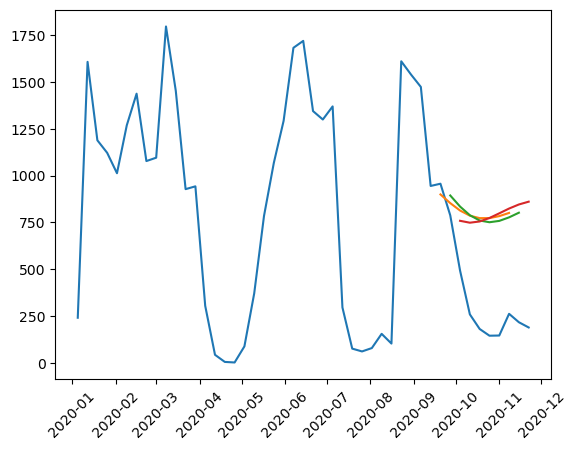

In [116]:
plt.plot(prod_list[prod_idx[69]]);
plt.xticks(rotation=45);

for i in range(n_windows):
    plt.plot(lst[i].ds, lst[i].AutoARIMA)

## Prediction accuracy

In [102]:

mae_by_series = (
    cv.groupby("unique_id")
      .apply(
          lambda x: 
              (abs(x["y"] - x["AutoARIMA"])).mean()
      )
      .rename("MAE")
)

mae_sorted = mae_by_series.sort_values(ascending=False)
for id_val, val in zip(mae_sorted.index, mae_sorted):
    print(prod_idx.get_loc(id_val), val)

69 474.1438903808594


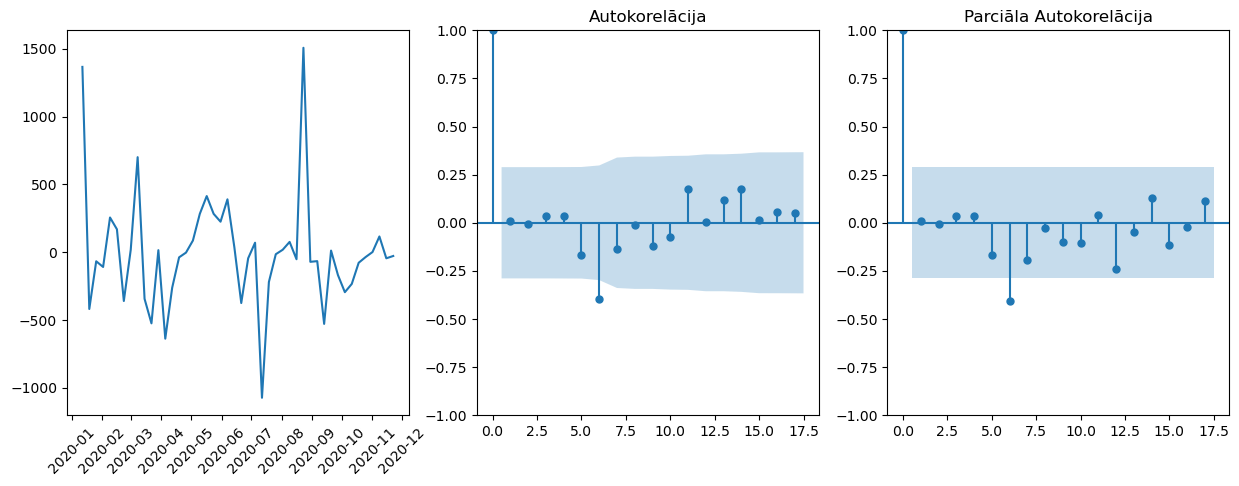

In [10]:
fig2_2, axs2_2 = plt.subplots(1, 3, figsize=(15, 5))

axs2_2[0].plot(prod_list[prod_idx[69]].diff(1));
axs2_2[0].tick_params("x", labelrotation=45);
plot_acf(prod_list[prod_idx[69]].diff(1).dropna(), ax=axs2_2[1], title="Autokorelācija");
plot_pacf(prod_list[prod_idx[69]].diff(1).dropna(), ax=axs2_2[2], title="Parciāla Autokorelācija");

In [11]:
scale_param = 0.1
am = arch_model(prod_list[prod_idx[69]].diff(1).dropna() * scale_param, mean="Zero", vol="GARCH")
res = am.fit(disp='off')
res

                       Zero Mean - GARCH Model Results                        
Dep. Variable:               order_nr   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.022
Vol Model:                      GARCH   Log-Likelihood:               -236.739
Distribution:                  Normal   AIC:                           479.478
Method:            Maximum Likelihood   BIC:                           484.964
                                        No. Observations:                   46
Date:                Wed, Jul 01 2026   Df Residuals:                       46
Time:                        16:45:51   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega        541.7153    375.259      1.444      0.149 

In [5]:
ser = prod_list[prod_idx[69]].diff(1).dropna()

tests, forecast, mae = mae_crossval(ser, n_splits=5, scale_param=0.1)

sum(mae) / len(mae)

223.05714285714288

In [6]:
forecast

[array([0., 0., 0., 0., 0., 0., 0.]),
 array([0., 0., 0., 0., 0., 0., 0.]),
 array([0., 0., 0., 0., 0., 0., 0.]),
 array([0., 0., 0., 0., 0., 0., 0.]),
 array([0., 0., 0., 0., 0., 0., 0.])]

In [7]:
tests

[date
 2020-03-29     15.0
 2020-04-05   -638.0
 2020-04-12   -262.0
 2020-04-19    -38.0
 2020-04-26     -3.0
 2020-05-03     86.0
 2020-05-10    283.0
 Name: order_nr, dtype: float64,
 date
 2020-05-17    414.0
 2020-05-24    283.0
 2020-05-31    225.0
 2020-06-07    390.0
 2020-06-14     37.0
 2020-06-21   -375.0
 2020-06-28    -45.0
 Name: order_nr, dtype: float64,
 date
 2020-07-05      70.0
 2020-07-12   -1074.0
 2020-07-19    -220.0
 2020-07-26     -15.0
 2020-08-02      18.0
 2020-08-09      76.0
 2020-08-16     -52.0
 Name: order_nr, dtype: float64,
 date
 2020-08-23    1508.0
 2020-08-30     -71.0
 2020-09-06     -66.0
 2020-09-13    -529.0
 2020-09-20      12.0
 2020-09-27    -169.0
 2020-10-04    -295.0
 Name: order_nr, dtype: float64,
 date
 2020-10-11   -234.0
 2020-10-18    -78.0
 2020-10-25    -36.0
 2020-11-01      1.0
 2020-11-08    116.0
 2020-11-15    -45.0
 2020-11-22    -28.0
 Name: order_nr, dtype: float64]